# 01 · P300 speller: from flashes to ERPs

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Load a real P300 speller recording, inspect target imbalance, visualize event-related activity and extract temporal features.

**Data:** BNCI2014-009, subject 1, three sessions; MOABB → MNE

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Try the practice task in its workspace.
4. Continue to the worked solution and compare the reasoning, not just the number.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Try it” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## The question for today

A student sees a positive bump around 300 ms and calls it a working speller. Your task is to slow down that conclusion: identify what was flashed, which flashes were attended, how the EEG was aligned, and what averaging hides. By the end, you will have a defensible feature matrix, not yet a character decoder.

### By the end you should be able to

- Explain target versus non-target labels in a row/column attention task.
- Derive why class averaging improves random-noise visibility but not single-trial reliability.
- Construct temporal-window features and keep trial/session identifiers aligned.
- Interpret an ERP plot without selecting features on held-out evaluation data.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

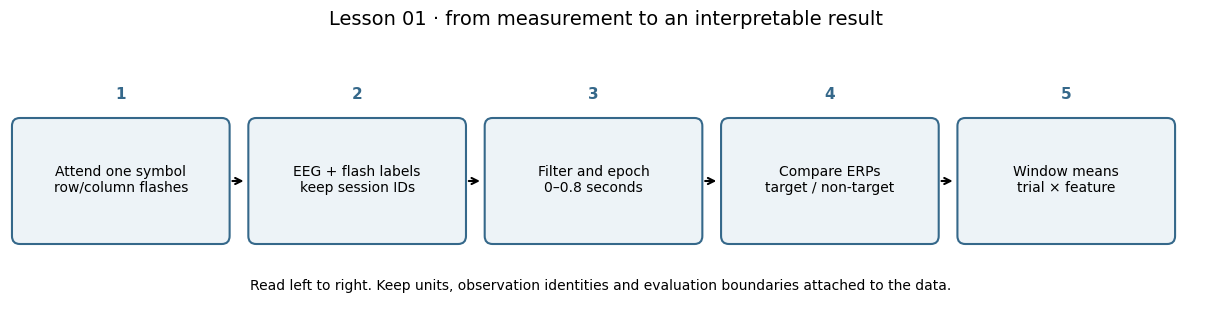

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Attend one symbol\nrow/column flashes', 'EEG + flash labels\nkeep session IDs', 'Filter and epoch\n0–0.8 seconds', 'Compare ERPs\ntarget / non-target', 'Window means\ntrial × feature']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 01 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Attend one symbol: row/column flashes → EEG + flash labels: keep session IDs → Filter and epoch: 0–0.8 seconds → Compare ERPs: target / non-target → Window means: trial × feature.

## Symbols and a calculation by hand

$X_{nct}$: trial $n$, channel $c$, sample $t$; $N_k$: trials of class $k$; $W$: selected time samples.

### Derive the operation before calling the library

Start with a class-specific average $\bar X_{kct}=N_k^{-1}\sum_{n:y_n=k}X_{nct}$. If independent noise has variance $\sigma^2$, the variance of its mean is $N_k\sigma^2/N_k^2=\sigma^2/N_k$; the standard deviation is therefore $\sigma/\sqrt{N_k}$. Four times as many trials halves this noise standard deviation, not quarters it.

For one trial, one channel and window samples $[2,4,6]\,\mu V$, the temporal feature is $(2+4+6)/3=4\,\mu V$. Repeating this operation for $C$ channels and $J$ windows produces $CJ$ columns. With 16 channels and four windows, expect 64 features per trial. The trial axis is never averaged away before classification.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Begin with the experiment, not the classifier

Imagine a 6×6 grid. A person attends one symbol while rows and columns intensify. A flash is a target if its group contains that symbol. In a complete 12-group repetition, two groups are targets. The target rate is therefore $2/12=1/6$ for that idealized schedule. This explains class imbalance before looking at any machine-learning output. It does not tell us the complete timing or sequence metadata of a particular file; those must come from its experimental record.

The label belongs to a **flash**, while the communication goal belongs to a **character**. Several flash decisions may be needed for one character. Confusing those units leads to invalid speed estimates and leakage when flashes from the same intended symbol appear on both sides of a split. Our real-data analysis holds out sessions to preserve a meaningful boundary.

### What an ERP actually estimates

Write a single epoch as $X_i(t)=s_{y_i}(t)+\epsilon_i(t)$. The class average estimates $s_k(t)$ if nuisance variation averages away. In reality, latency jitter, overlapping responses and nonstationarity violate this simple model. Averaging epochs with variable peak latency can broaden the response and reduce its apparent height. A small average does not prove that every individual trial lacks a response.

For a mean-amplitude feature, a window is part of the hypothesis. A 0.25–0.40 s average measures voltage over an interval, whereas a peak feature searches for an extreme. Searching over many times can pick noise, especially with few trials. We begin with means because their definition is stable and easy to audit. The windows used below are fixed teaching choices; improving them requires training-only validation.

### Read the loader as a processing contract

`P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)` is not merely a file download. It requests filtering, epoch extraction and resampling. Applying another filter without recognizing this would change the pipeline twice. `return_epochs=True` retains MNE metadata and gives volt-valued EEG. Always print the returned labels, shapes and metadata. Keep `metadata_p300` alongside the arrays: a shuffled feature table without a correspondingly shuffled session column silently corrupts evaluation.

## Visual intuition · Connect the speller grid to the flash timeline

**Try it:** Count the highlighted row and column. Why are two of twelve groups targets in one idealized repetition?

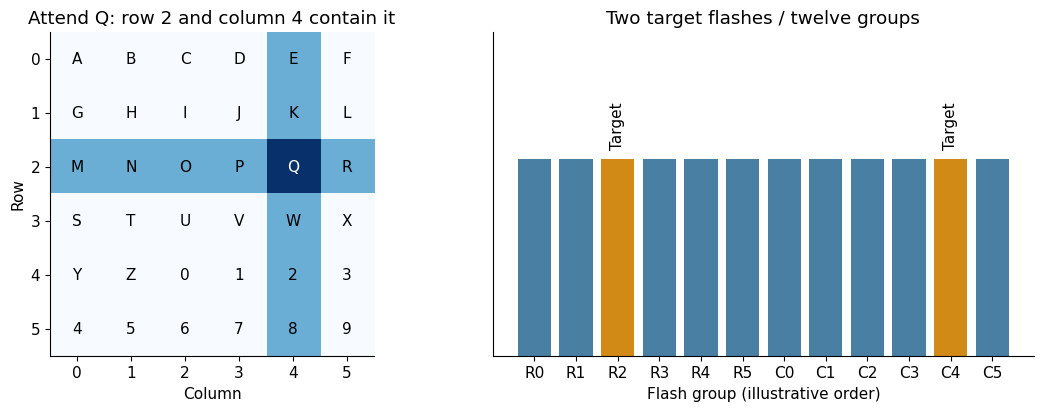

In [3]:
vis_grid=np.array(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')).reshape(6,6)
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
vis_target=(2,4)
vis_mask=np.zeros((6,6));vis_mask[2,:]=1;vis_mask[:,4]=1;vis_mask[2,4]=2
axes[0].imshow(vis_mask,cmap='Blues',vmin=0,vmax=2)
for row in range(6):
    for col in range(6):axes[0].text(col,row,vis_grid[row,col],ha='center',va='center',color='white' if (row,col)==vis_target else 'black')
axes[0].set(xticks=range(6),yticks=range(6),xlabel='Column',ylabel='Row',title='Attend Q: row 2 and column 4 contain it')
vis_flash=np.arange(12);vis_targets=np.isin(vis_flash,[2,10])
axes[1].bar(vis_flash,np.ones(12),color=['#d28a16' if x else '#497fa3' for x in vis_targets])
for k in [2,10]:axes[1].text(k,1.05,'Target',ha='center',rotation=90,va='bottom')
axes[1].set(xticks=range(12),xticklabels=[f'R{i}' for i in range(6)]+[f'C{i}' for i in range(6)],ylim=(0,1.65),yticks=[],xlabel='Flash group (illustrative order)',title='Two target flashes / twelve groups')
plt.show()

### Worked interpretation

Q is at zero-based row 2, column 4. A row flash and a column flash both contain Q, but each flash includes other characters too. Character selection requires combining evidence with flash identity. This diagram is a protocol illustration, not the downloaded dataset’s actual flash schedule.

## Guided practice 1 · count target flashes

Construct one idealized repetition for a target at row 2, column 4 (zero-based). This is a small experiment-design model, not a reconstruction of the downloaded recording.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_flash_groups=np.arange(12)
demo_target_row,demo_target_column=2,4
demo_target=(demo_flash_groups==demo_target_row)|(demo_flash_groups==6+demo_target_column)
print(pd.DataFrame({'flash_group':demo_flash_groups,'is_target':demo_target}))
print('Target fraction:',demo_target.mean())
print('Always non-target accuracy:',1-demo_target.mean())

    flash_group  is_target
0             0      False
1             1      False
2             2       True
3             3      False
4             4      False
5             5      False
6             6      False
7             7      False
8             8      False
9             9      False
10           10       True
11           11      False
Target fraction: 0.16666666666666666
Always non-target accuracy: 0.8333333333333334


### Why this result makes sense

The easy-looking 83.3% majority accuracy follows from the stimulus schedule. It is not evidence that EEG contains useful predictive information.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · derive window averaging

For samples $[2,4,6]$ µV in a window, the mean is 4 µV. In a batch, compute that operation independently for every trial and channel. The output must lose the time axis and keep the other two.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_cube=np.array([[[2.,4.,6.,100.],[1.,3.,5.,100.]],
                    [[0.,2.,4.,100.],[2.,2.,2.,100.]]])*1e-6
demo_times=np.array([.2,.3,.4,.5])
demo_mask=(demo_times>=.2)&(demo_times<.5)
demo_features=demo_cube[:,:,demo_mask].mean(-1)
print('Features in µV:\n',demo_features*1e6)
assert demo_features.shape==(2,2)
assert np.isclose(demo_features[0,0]*1e6,4)

Features in µV:
 [[4. 3.]
 [2. 2.]]


### Why this result makes sense

The large value at the excluded endpoint must not contribute. State whether a window includes its right endpoint; otherwise two adjacent windows may accidentally count a sample twice.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · latency jitter changes the average

Generate positive responses with the same amplitude but different latencies. Predict whether averaging preserves peak height. Use the same y-axis for the two conditions.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

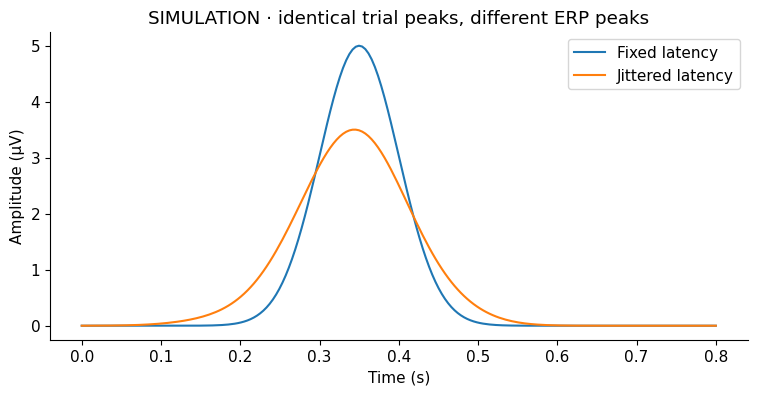

In [6]:
demo_times=np.linspace(0,.8,200)
fixed=np.array([5*np.exp(-.5*((demo_times-.35)/.05)**2) for _ in range(100)])
jittered=np.array([5*np.exp(-.5*((demo_times-center)/.05)**2)
                   for center in rng.normal(.35,.06,100)])
fig,ax=plt.subplots()
ax.plot(demo_times,fixed.mean(0),label='Fixed latency')
ax.plot(demo_times,jittered.mean(0),label='Jittered latency')
ax.set(xlabel='Time (s)',ylabel='Amplitude (µV)',title='SIMULATION · identical trial peaks, different ERP peaks')
ax.legend();plt.show()

### Why this result makes sense

A broader, lower ERP can arise without reducing the amplitude of any single response. This is one reason to inspect single-trial images as well as averages.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · compare mean and maximum estimators

With independent zero-mean noise, the window mean is centered near zero but the maximum tends to be positive. This illustrates selection bias in a peak search.

**Try it on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

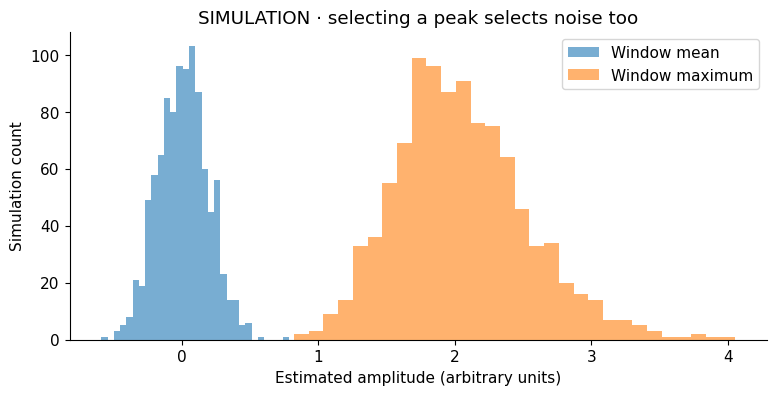

In [7]:
noise_windows=rng.normal(0,1,(1000,30))
fig,ax=plt.subplots()
ax.hist(noise_windows.mean(1),bins=30,alpha=.6,label='Window mean')
ax.hist(noise_windows.max(1),bins=30,alpha=.6,label='Window maximum')
ax.set(xlabel='Estimated amplitude (arbitrary units)',ylabel='Simulation count',title='SIMULATION · selecting a peak selects noise too')
ax.legend();plt.show()

### Why this result makes sense

A positive maximum is expected even with no signal. A feature can be useful for prediction without being an unbiased estimate of ERP amplitude, but that distinction must be explicit.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Implement a temporal feature

Complete `window_mean` below. Use a half-open interval [start, stop). Preserve the trial and channel axes and reject an empty window with a useful error.

**Try it:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def window_mean(data, times, start, stop):
    # TODO: data is trials × channels × time; return trials × channels.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def window_mean(data,times,start,stop):
    mask=(times>=start)&(times<stop)
    if not mask.any(): raise ValueError('Empty feature window')
    return data[:,:,mask].mean(-1)

In [10]:
answer=window_mean(demo_cube,np.array([.2,.3,.4,.5]),.2,.5)
if answer is not None:
    np.testing.assert_allclose(answer,np.array([[4,3],[2,2]])*1e-6); print('Window checks passed.')
else:
    print('Exercise pending: implement window_mean.')

Window checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A row/column speller briefly intensifies groups of symbols. The attended group is a target; other groups are non-targets. A target can evoke a positive deflection several hundred milliseconds later, but latency and amplitude vary and a P300 is not guaranteed on each flash. Attention, fatigue and overlapping responses matter.

An epoch is $X_i(c,\tau)=x_c(t_i+\tau)$. An ERP is $\bar X_k(c,\tau)=N_k^{-1}\sum_{i:y_i=k}X_i(c,\tau)$. Averaging reduces independent zero-mean noise approximately as $1/\sqrt{N_k}$; this does not remove systematic artifacts. A time-window feature is $z_{icw}=|W|^{-1}\sum_{\tau\in W}X_i(c,\tau)$.

We use BNCI2014-009 through MOABB. It is a **P300 speller dataset, not BCI Competition II/III speller data**. MOABB returns MNE epochs and preserves session/run metadata, but its binary paradigm interface does not provide enough character/flash identity for verified text decoding. Notebook 02 separates real target detection from a controlled character-decoding exercise.

We choose a 0.5–20 Hz passband and 0–0.8 s epochs. No pre-stimulus baseline is available in this extraction; do not claim one was applied. Nearby flash epochs overlap: randomly splitting individual flashes risks shared signal and character context across train and test. Hold out entire sessions.

## Load real speller epochs
The loader filters and resamples; it returns EEG in volts. Check class labels rather than assuming numeric codes.

MOABB supplies an MNE Epochs object with labels and trial metadata. The P300 paradigm specifies filtering, epoch limits and resampling in one place. The label conversion explicitly identifies the target class; inspect the printed label counts before proceeding. This dataset is a public speller dataset accessed through MOABB, not a built-in MNE competition archive.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Import the named tools used in this step.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Declare the public P300 preprocessing and epoching contract before loading.

**5.** Expose the numerical array; EEG values are in volts and the final axis is time.

**6.** Make an explicit NumPy vector while preserving its current row order.

**7.** Expose the numerical array; EEG values are in volts and the final axis is time.

In [11]:
# Import the named tools used in this step.
from moabb.datasets import BNCI2014_009
# Import the named tools used in this step.
from moabb.paradigms import P300
# Store this intermediate result so the next operation can be traced and inspected.
dataset = BNCI2014_009()
# Declare the public P300 preprocessing and epoching contract before loading.
paradigm = P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)
# Expose the numerical array; EEG values are in volts and the final axis is time.
epochs, labels, metadata_p300 = paradigm.get_data(dataset=dataset, subjects=[1], return_epochs=True)
# Make an explicit NumPy vector while preserving its current row order.
y = (np.asarray(labels) == 'Target').astype(int)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)

<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
<local-python-environment>/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


### Step 1.2 · trace the next operation

**1.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**2.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**3.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**4.** Make an explicit NumPy vector while preserving its current row order.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [12]:
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
session = metadata_p300['session'].astype(str).to_numpy()
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert X.shape[0] == len(y) == len(session)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert set(np.unique(y)) == {0, 1}
# Make an explicit NumPy vector while preserving its current row order.
print(pd.crosstab(session, np.asarray(labels)))
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Shape:', X.shape, 'sampling:', epochs.info['sfreq'], 'Hz')

col_0  NonTarget  Target
row_0                   
0            480      96
1            480      96
2            480      96
Shape: (1728, 16, 103) sampling: 128.0 Hz


### Inspect and interpret

Inspect the session column and the target/non-target counts. Verify that `len(y)`, `len(metadata_p300)` and the number of epochs agree. These three objects must retain the same row ordering throughout analysis.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Audit class imbalance with actual counts

**Try it:** Calculate target prevalence and the accuracy of always predicting non-target in each session. Do this from labels rather than assuming the idealized 1/6 rate.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Group by the session vector that has one entry per trial.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
lab_counts=pd.DataFrame({'session':session,'target':y}).groupby('session').target.agg(['sum','count'])
lab_counts['target_fraction']=lab_counts['sum']/lab_counts['count']
lab_counts['always_non_target_accuracy']=1-lab_counts['target_fraction']
print(lab_counts)

         sum  count  target_fraction  always_non_target_accuracy
session                                                         
0         96    576         0.166667                    0.833333
1         96    576         0.166667                    0.833333
2         96    576         0.166667                    0.833333


### Interpret and check

The table is a dataset audit. The idealized schedule motivates the expected imbalance, but the actual counts are the evidence. A high majority-class accuracy does not mean targets can be detected.

## Inspect the ERP
Plot the nearest available parietal channel. These averages are descriptive; do not choose a classification time window using the held-out session.

We select a parietal sensor by its name and average each class separately. Multiplication by one million changes only the displayed units. The shaded region marks a predeclared response interval, not a region selected because the plotted difference happened to be largest.

### Step 2.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Store this intermediate result so the next operation can be traced and inspected.

In [15]:
# Store this intermediate result so the next operation can be traced and inspected.
channel = 'Pz' if 'Pz' in epochs.ch_names else epochs.ch_names[-1]
# Store this intermediate result so the next operation can be traced and inspected.
c = epochs.ch_names.index(channel)

### Step 2.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Render the completed figure and inspect labels, units and the comparison.

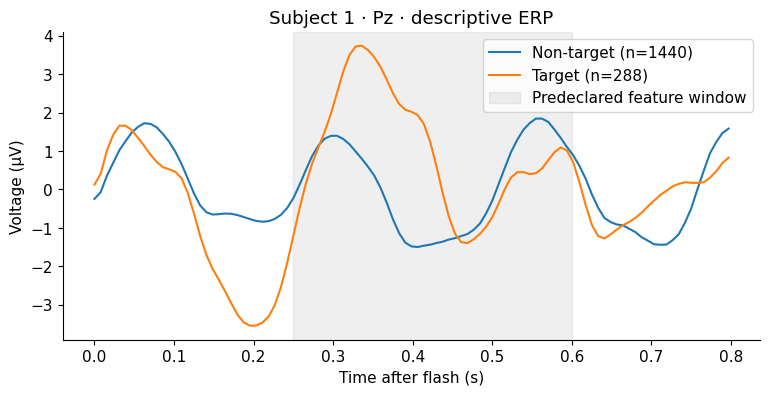

In [16]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for label, name in [(0, 'Non-target'), (1, 'Target')]:
    ax.plot(epochs.times, X[y == label, c].mean(0) * 1000000.0, label=f'{name} (n={(y == label).sum()})')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.axvspan(0.25, 0.6, color='gray', alpha=0.12, label='Predeclared feature window')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlabel='Time after flash (s)', ylabel='Voltage (µV)', title=f'Subject 1 · {channel} · descriptive ERP')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Describe polarity, approximate latency and overlap. A class-average difference motivates a feature but does not establish single-trial accuracy. These all-session plots are descriptive; do not use them to tune the later held-out-session classifier.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Interpret a small average without overclaiming

**Try it:** Give two explanations for a small target ERP that do not imply the brain produced no response.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Separate single-trial amplitude from alignment and noise.

### Worked solution

One explanation is variable response latency: positive peaks occur at different times and broaden the average. Another is heterogeneous responses or limited retained trials. Neither explanation is proven by the mean alone; inspect trial-level data and the recording protocol before choosing among them.

## Extract interpretable features
Use several predeclared windows so a classifier can combine channels and latencies.

Each window contributes one mean per channel, then concatenation creates a trial × feature table. This compression retains coarse temporal structure while avoiding one independent model weight for every sample. The half-open window masks keep adjacent windows from double-counting boundary samples.

### Step 3.1 · trace the next operation

**1.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**2.** Join arrays along the declared axis; preserve the trial ordering.

**3.** Check a required invariant now so a silent alignment or numerical error cannot propagate.

**4.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [17]:
# Make the analysis choice visible and fixed before inspecting evaluation performance.
windows = [(0.1, 0.25), (0.25, 0.4), (0.4, 0.6), (0.6, 0.8)]
# Join arrays along the declared axis; preserve the trial ordering.
features = np.concatenate([X[:, :, (epochs.times >= a) & (epochs.times < b)].mean(-1) for a, b in windows], axis=1)
# Check a required invariant now so a silent alignment or numerical error cannot propagate.
assert features.shape == (len(y), len(epochs.ch_names) * len(windows))
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Features:', features.shape, 'target fraction:', y.mean())
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Always non-target accuracy:', (y == 0).mean(), 'balanced accuracy: 0.5')

Features: (1728, 64) target fraction: 0.16666666666666666
Always non-target accuracy: 0.8333333333333334 balanced accuracy: 0.5


### Inspect and interpret

Calculate the expected number of columns from channels × windows and compare it with the printed shape. Identify which columns correspond to the first time window. A feature name should make both channel and latency recoverable.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Build one feature by hand and compare with the matrix

**Try it:** For the first trial and first channel, compute the first window mean. Find the same value in features.

**My reasoning / hand calculation:** _write here._

In [18]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The first block of columns corresponds to the first window; channel order follows epochs.ch_names.

### Worked solution

Run the following calculation after attempting your own version.

In [19]:
lab_mask=(epochs.times>=windows[0][0])&(epochs.times<windows[0][1])
lab_value=X[0,0,lab_mask].sum()/lab_mask.sum()
print('Channel:',epochs.ch_names[0],'window:',windows[0],'samples:',lab_mask.sum())
print('Manual / matrix feature (µV):',lab_value*1e6,features[0,0]*1e6)
assert np.isclose(lab_value,features[0,0])

Channel: Fz window: (0.1, 0.25) samples: 19
Manual / matrix feature (µV): 0.9142604697122751 0.9142604697122755


### Interpret and check

The sum divided by the selected sample count reproduces the feature. A temporal mean removes detailed within-window timing while retaining the average voltage. It does not average across trials or channels.

## Practice 5 · Keep flash and character units separate

**Try it:** Can the target/non-target feature matrix alone produce a defensible real spelling accuracy? List the missing information.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Character aggregation needs the experimental sequence, not just a binary label.

### Worked solution

No. It needs the identity of each flashed group, the intended character, repetition boundaries and character-selection boundaries. The real binary detector can be evaluated without all of that metadata, but character accuracy and typing speed cannot be inferred from binary AUC.

## Practice 6 · explain the complete method

Without looking back, explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

An ERP is a class-conditional average, not a guarantee of reliable single-trial detection. A feature matrix preserves trials while compressing each waveform into pre-specified summaries. Binary flash labels alone do not provide all metadata required for real character decoding.

## If your result is different

If labels contain no targets, inspect the returned label strings before converting them to 0/1. If feature windows are empty, inspect epochs.times and the half-open masks.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[Dataset documentation](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html) · [MNE epochs](https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.